In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1 Importando o arquivo

In [2]:
arquivo = r"https://raw.githubusercontent.com/vbomura/tc5/03b05a676fa48320170229c8be9c7a22fe5c0f7f/Codigos/base_anos_limpo.xlsx"

df = pd.read_excel(arquivo)

# 1. Adequação do nível (IAN): Qual é o perfil geral de defasagem dosalunos (IAN) e como ele evolui ao longo do ano?

In [3]:
# df.sample(25)
df['fase'] = df['fase'].astype(str).replace({
    '0': 'ALFA',
    '1': 'FASE 1',
    '2': 'FASE 2',
    '3': 'FASE 3',
    '4': 'FASE 4',
    '5': 'FASE 5',
    '6': 'FASE 6',
    '7': 'FASE 7',
})
df['fase'].unique()

array(['FASE 7', 'FASE 6', 'FASE 5', 'FASE 4', 'FASE 3', 'FASE 2',
       'FASE 1', 'ALFA'], dtype=object)

## Analise por sexo

In [4]:
defasagens_escolhidas = [-3,-2,-1,0,1]
# defasagens_escolhidas = df['defasagem'].unique()

df_plot = df[df['defasagem'].isin(defasagens_escolhidas)].copy()

In [5]:
agrupado = (
    df_plot
    .groupby(['ano_aba', 'genero', 'defasagem'])
    .size()
    .reset_index(name='qtd')
)

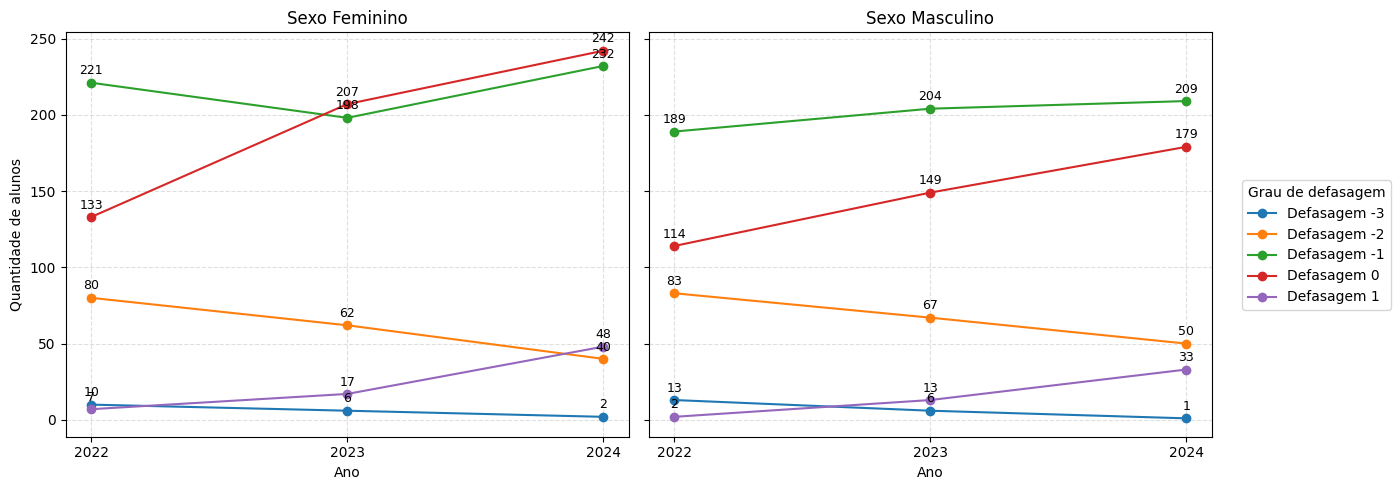

In [6]:
sexos = ['Feminino', 'Masculino']  # ajuste se seus rótulos forem diferentes
anos = sorted(df_plot['ano_aba'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, sexo in zip(axes, sexos):
    dados_sexo = agrupado[agrupado['genero'] == sexo]

    for grau in defasagens_escolhidas:
        dados_grau = dados_sexo[dados_sexo['defasagem'] == grau]

        ax.plot(
            dados_grau['ano_aba'],
            dados_grau['qtd'],
            marker='o',
            label=f'Defasagem {grau}'
        )

        # 🔢 Valor em cada ponto
        for x, y in zip(dados_grau['ano_aba'], dados_grau['qtd']):
            ax.annotate(
                str(y),
                (x, y),
                textcoords="offset points",
                xytext=(0, 6),
                ha='center',
                fontsize=9
            )
    ax.set_title(f'Sexo {sexo}')
    ax.set_xlabel('Ano')
    ax.grid(True, linestyle='--', alpha=0.4)

    # Força eixo X com anos inteiros
    ax.set_xticks(anos)
    ax.set_xticklabels([str(int(a)) for a in anos])

axes[0].set_ylabel('Quantidade de alunos')

# Legenda única
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title='Grau de defasagem',
    loc='center right'
)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

## Analise por fase

In [7]:
df['tipo_defasagem'] = df['defasagem'].apply(
    lambda x: 'Abaixo de zero' if x < 0 else 'Acima de zero'
)

In [8]:
agrupado = (
    df
    .groupby(['ano_aba', 'fase', 'tipo_defasagem'])
    .size()
    .reset_index(name='qtd')
)

In [9]:
tabela = (
    agrupado
    .pivot_table(
        index=['ano_aba', 'fase'],
        columns='tipo_defasagem',
        values='qtd',
        fill_value=0
    )
)


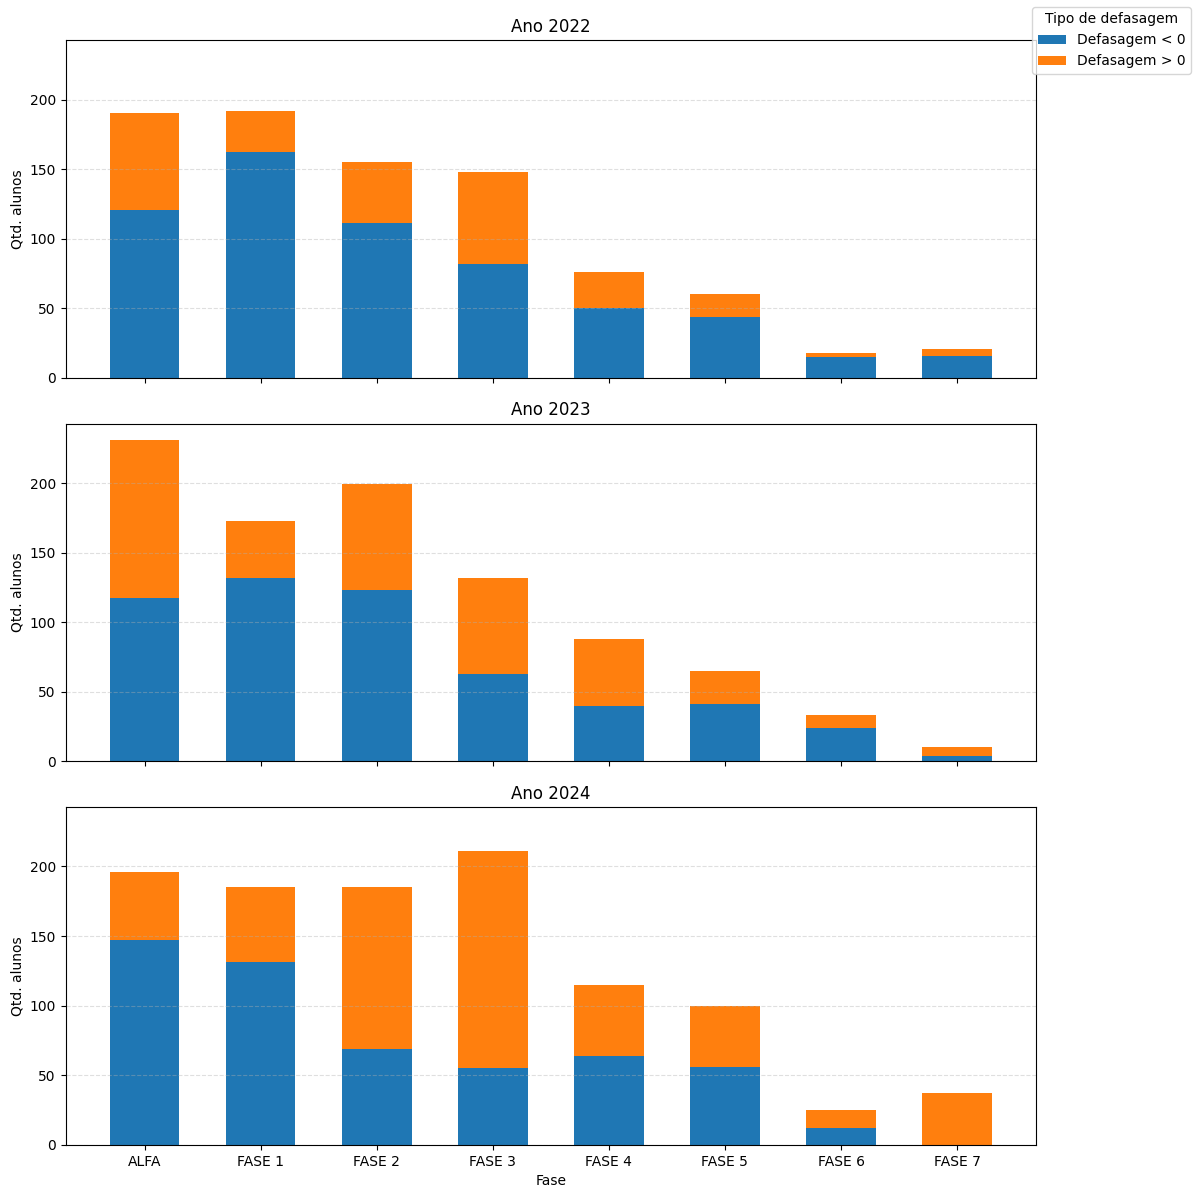

In [10]:
anos = sorted(tabela.index.get_level_values('ano_aba').unique())
fases = sorted(tabela.index.get_level_values('fase').unique())

x = np.arange(len(fases))
largura = 0.6  # barras mais largas (não há mais anos lado a lado)

# 🎨 cores fixas
cor_abaixo = '#1f77b4'  # azul
cor_acima = '#ff7f0e'   # laranja

fig, axes = plt.subplots(
    nrows=len(anos),
    ncols=1,
    figsize=(12, 4 * len(anos)),
    sharex=True,
    sharey=True
)

# Garante que axes seja iterável mesmo com 1 gráfico
if len(anos) == 1:
    axes = [axes]

for ax, ano in zip(axes, anos):
    dados_ano = tabela.loc[ano]

    abaixo = dados_ano['Abaixo de zero'].values
    acima = dados_ano['Acima de zero'].values

    # Barra empilhada
    ax.bar(
        x,
        abaixo,
        width=largura,
        color=cor_abaixo,
        label='Defasagem < 0'
    )

    ax.bar(
        x,
        acima,
        width=largura,
        bottom=abaixo,
        color=cor_acima,
        label='Defasagem > 0'
    )

    ax.set_title(f'Ano {ano}')
    ax.set_ylabel('Qtd. alunos')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

# Eixo X (apenas no último gráfico)
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(fases, rotation=0)
axes[-1].set_xlabel('Fase')

# Legenda única
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title='Tipo de defasagem',
    loc='upper right'
)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()


Quando analisamos em relação ao sexo podemos ver uma queda muito positiva em reção a defasagem -2 e -3, mostrando que menos casos de defasagem grande.
Podemos ver que para ambos os gêneros também tivemos uma boa "normalização", ou seja, inscritos que estão na fase adequada (Defasagem 0)
Alunos que estão com um nível de defasagem mostram que o grupo feminino conseguiu ter uma querda, mas em 2024 voltou a subir.
Vemos um aumento relativamente constante no úblico masculino

Temos uma tendência de alunos terem defasagem nas primeira (alfa 1, alfa 2 e alfa 3), movimento que ficou claro em 2024

# 2. Desempenho acadêmico (IDA)

In [11]:
df.head()

,ra,fase,turma,nome_anonimizado,idade,genero,ano_ingresso,instituicao_de_ensino,pedra,inde,...,ing,ipv,ian,fase_ideal_original,defasagem,ano_aba,fase_ideal,ipp,fase_original,tipo_defasagem
0,RA-1,FASE 7,A,Aluno-1,19,Feminino,2016,Escola Pública,Quartzo,5.783,...,6.0,7.278,5.0,Fase 8 (Universitários),-1,2022,FASE 8,NaN,NaN,Abaixo de zero
1,RA-2,FASE 7,A,Aluno-2,17,Feminino,2017,Rede Decisão,Ametista,7.055,...,9.7,6.778,10.0,Fase 7 (3º EM),0,2022,FASE 7,NaN,NaN,Acima de zero
2,RA-3,FASE 7,A,Aluno-3,17,Feminino,2016,Rede Decisão,Ágata,6.591,...,6.9,7.556,10.0,Fase 7 (3º EM),0,2022,FASE 7,NaN,NaN,Acima de zero
3,RA-4,FASE 7,A,Aluno-4,17,Masculino,2017,Rede Decisão,Quartzo,5.951,...,8.7,5.278,10.0,Fase 7 (3º EM),0,2022,FASE 7,NaN,NaN,Acima de zero
4,RA-5,FASE 7,A,Aluno-5,17,Feminino,2016,Rede Decisão,Ametista,7.427,...,5.7,7.389,10.0,Fase 7 (3º EM),0,2022,FASE 7,NaN,NaN,Acima de zero


In [12]:
tabela = (
    df
    .groupby(['ano_aba', 'fase'])['ida']
    .mean()
    .reset_index()
    .pivot(index='ano_aba', columns='fase', values='ida')
    .round(2)
)  

C:\Users\bryan\AppData\Local\Temp\ipykernel_1576\766528749.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '⬆️ 7.42' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  tabela_display.iloc[i, j] = f'⬆️ {atual:.2f}'
C:\Users\bryan\AppData\Local\Temp\ipykernel_1576\766528749.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '⬆️ 6.81' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  tabela_display.iloc[i, j] = f'⬆️ {atual:.2f}'
C:\Users\bryan\AppData\Local\Temp\ipykernel_1576\766528749.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '⬆️ 6.74' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  tabela_display.iloc[i, 

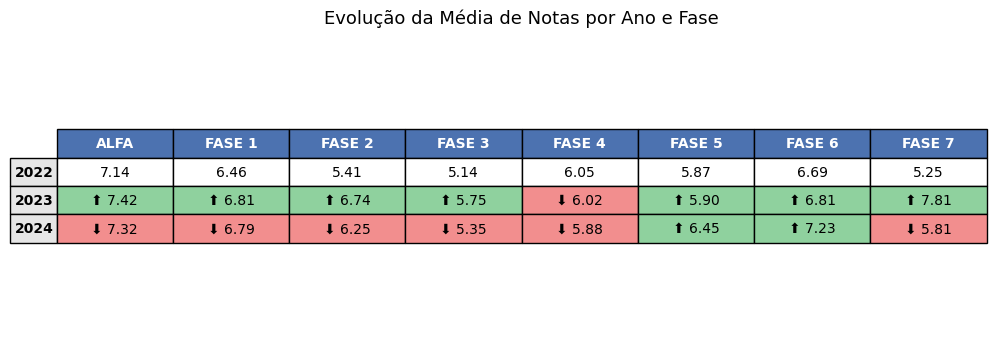

In [13]:
# garante ordenação por ano
tabela = tabela.sort_index()

# ---------------------------------
# Criar versão textual com setas
# ---------------------------------
tabela_display = tabela.copy()

for j in range(len(tabela.columns)):
    for i in range(1, len(tabela.index)):
        atual = tabela.iloc[i, j]
        anterior = tabela.iloc[i - 1, j]

        if (
            isinstance(atual, (int, float)) and
            isinstance(anterior, (int, float))
        ):
            if atual > anterior:
                tabela_display.iloc[i, j] = f'⬆️ {atual:.2f}'
            elif atual < anterior:
                tabela_display.iloc[i, j] = f'⬇️ {atual:.2f}'
            else:
                tabela_display.iloc[i, j] = f'➖ {atual:.2f}'
        elif isinstance(atual, (int, float)):
            tabela_display.iloc[i, j] = f'{atual:.2f}'

# primeiro ano (sem comparação)
for j in range(len(tabela.columns)):
    if isinstance(tabela.iloc[0, j], (int, float)):
        tabela_display.iloc[0, j] = f'{tabela.iloc[0, j]:.2f}'

# ---------------------------------
# Plot da tabela
# ---------------------------------
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

table = ax.table(
    cellText=tabela_display.fillna('-').values,
    colLabels=tabela_display.columns,
    rowLabels=tabela_display.index,
    cellLoc='center',
    loc='center'
)

# ---------------------------------
# Cabeçalho
# ---------------------------------
for j in range(len(tabela.columns)):
    header = table[(0, j)]
    header.set_facecolor('#4c72b0')
    header.set_text_props(color='white', weight='bold')

# ---------------------------------
# Índice (anos)
# ---------------------------------
for i in range(len(tabela.index)):
    idx_cell = table[(i + 1, -1)]
    idx_cell.set_facecolor('#e6e6e6')
    idx_cell.set_text_props(weight='bold')

# ---------------------------------
# Aplicar cores de aumento / queda
# ---------------------------------
for j in range(len(tabela.columns)):
    for i in range(1, len(tabela.index)):
        atual = tabela.iloc[i, j]
        anterior = tabela.iloc[i - 1, j]
        cell = table[(i + 1, j)]

        if (
            isinstance(atual, (int, float)) and
            isinstance(anterior, (int, float))
        ):
            if atual > anterior:
                cell.set_facecolor('#8fd19e')  # verde
            elif atual < anterior:
                cell.set_facecolor('#f28e8e')  # vermelho

# ---------------------------------
# Ajustes finais
# ---------------------------------
table.scale(1, 1.7)
plt.title('Evolução da Média de Notas por Ano e Fase', fontsize=13)
plt.show()
